In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── STEP 1: Load & Fix Column Names ─────────────────────────────
df = pd.read_csv('batch_process_data.csv')

# Rename to clean names
df.columns = [
    'Batch_ID', 'Time_Minutes', 'Phase', 'Temperature_C',
    'Pressure_Bar', 'Humidity_Percent', 'Motor_Speed_RPM',
    'Compression_Force_kN', 'Flow_Rate_LPM',
    'Power_Consumption_kW', 'Vibration_mm_s'
]

# Convert all except Batch_ID and Phase to numeric
numeric_cols = [
    'Time_Minutes', 'Temperature_C', 'Pressure_Bar',
    'Humidity_Percent', 'Motor_Speed_RPM', 'Compression_Force_kN',
    'Flow_Rate_LPM', 'Power_Consumption_kW', 'Vibration_mm_s'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Shape:", df.shape)
print("Dtypes:\n", df.dtypes)
print("Missing:\n", df.isnull().sum())
print("\nPhase counts:\n", df['Phase'].value_counts())

Shape: (14526, 11)
Dtypes:
 Batch_ID                 object
Time_Minutes            float64
Phase                    object
Temperature_C           float64
Pressure_Bar            float64
Humidity_Percent        float64
Motor_Speed_RPM         float64
Compression_Force_kN    float64
Flow_Rate_LPM           float64
Power_Consumption_kW    float64
Vibration_mm_s          float64
dtype: object
Missing:
 Batch_ID                0
Time_Minutes            1
Phase                   0
Temperature_C           1
Pressure_Bar            1
Humidity_Percent        1
Motor_Speed_RPM         1
Compression_Force_kN    1
Flow_Rate_LPM           1
Power_Consumption_kW    1
Vibration_mm_s          1
dtype: int64

Phase counts:
 Phase
Compression        4032
Quality_Testing    2649
Coating            1787
Drying             1731
Preparation        1228
Blending           1216
Granulation         994
Milling             888
Phase                 1
Name: count, dtype: int64


STEP 2 — Understand the Zeros (Phase-Dependent)
Why this matters:

In Preparation and QualityTesting phases, Motor_Speed_RPM, Compression_Force_kN, and Flow_Rate_LPM are all 0

This is not missing data — machines are genuinely OFF during those phases

If you imputed these zeros with median values, you would inject false data and ruin the model

This step just confirms the zeros are legitimate before proceeding

What you'll see:

text
Phase              Motor_Speed_RPM  Compression_Force_kN  Flow_Rate_LPM
Preparation              20                 20                 20
QualityTesting           60                 60                 60
Granulation               0                  0                  0


In [ ]:
# ── STEP 2: Handle Zeros (Phase-Dependent, NOT missing) ─────────
# Motor_Speed, Compression_Force, Flow_Rate = 0 in Preparation
# and QualityTesting — this is CORRECT data, do NOT impute these

print("\nZero counts per phase:")
zero_phases = df.groupby('Phase')[
    ['Motor_Speed_RPM','Compression_Force_kN','Flow_Rate_LPM']
].apply(lambda x: (x == 0).sum())
print(zero_phases)



Zero counts per phase:
                 Motor_Speed_RPM  Compression_Force_kN  Flow_Rate_LPM
Phase                                                                
Blending                       0                  1216           1216
Coating                        0                  1787              0
Compression                    0                     0           4032
Drying                         0                  1731              0
Granulation                    0                   994              0
Milling                        0                   888            888
Phase                          0                     0              0
Preparation                 1228                  1228           1228
Quality_Testing             2649                  2649           2649


STEP 3 — EDA & Visualization

Why each plot:

Plot	What it tells you
Histogram	Shape of each feature — is it normal, skewed, bimodal?
Boxplot by Phase	How power consumption and vibration differ across phases — Compression will have highest values
Correlation Heatmap	Which features are related to your targets. Strong correlation = good predictor
What to expect from your data:

Compression phase → highest Power_Consumption_kW (~40-60 kW)

Preparation phase → lowest power (~1-3 kW)

Vibration is highest during Milling and Compression

Temperature_C will be weakly correlated with power

Motor_Speed_RPM and Flow_Rate_LPM will be strongly correlated with power


Basic Stats:
        Time_Minutes  Temperature_C  Pressure_Bar  Humidity_Percent  \
count  14525.000000   14525.000000  14525.000000      14525.000000   
mean     121.468985      35.254545      0.977607         37.163200   
std       71.446431      13.124681      0.134651          9.906511   
min        0.000000      19.276826      0.445282         11.730968   
25%       60.000000      26.263992      0.891116         29.222648   
50%      121.000000      29.098475      0.978025         35.352979   
75%      181.000000      39.979592      1.063897         44.984324   
max      284.000000      75.157219      1.563296         69.348934   

       Motor_Speed_RPM  Compression_Force_kN  Flow_Rate_LPM  \
count     14525.000000          14525.000000   14525.000000   
mean        114.114629              3.224349       1.663517   
std         185.678997              5.531829       2.785680   
min           0.000000              0.000000       0.000000   
25%           0.000000              0.0

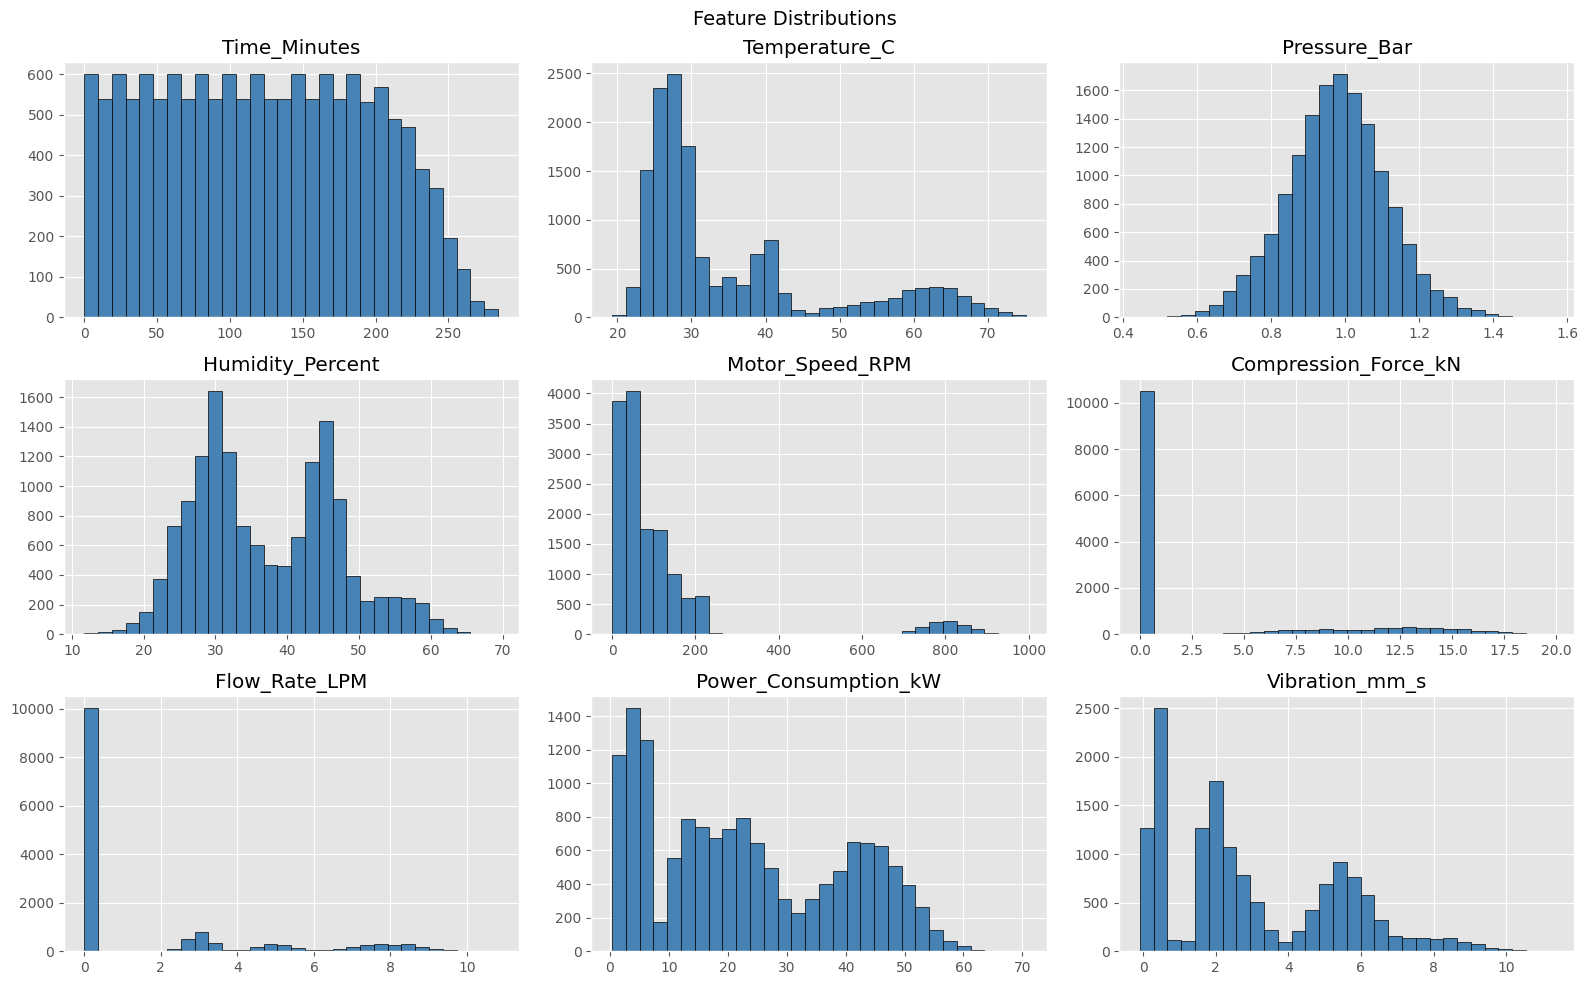

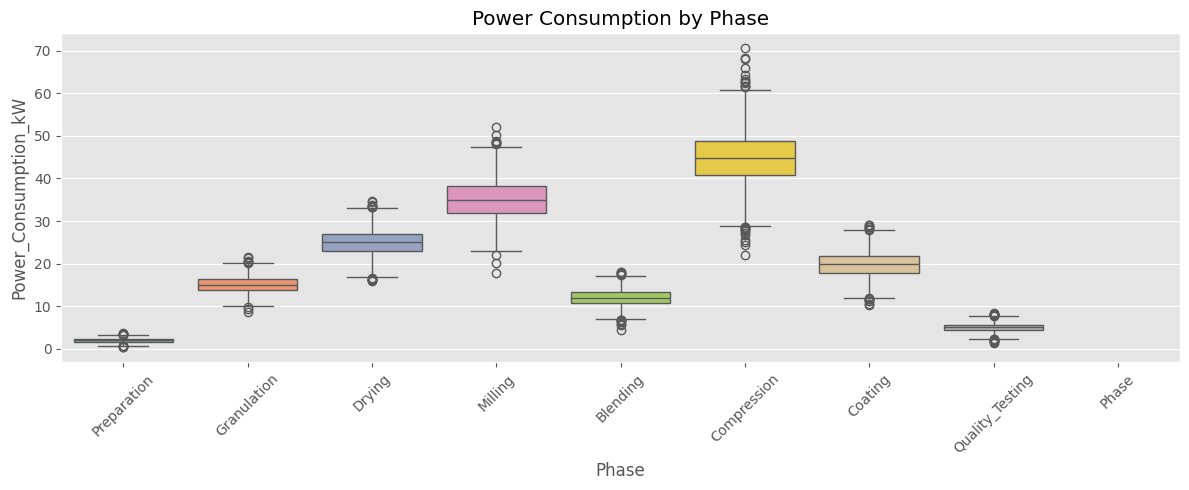

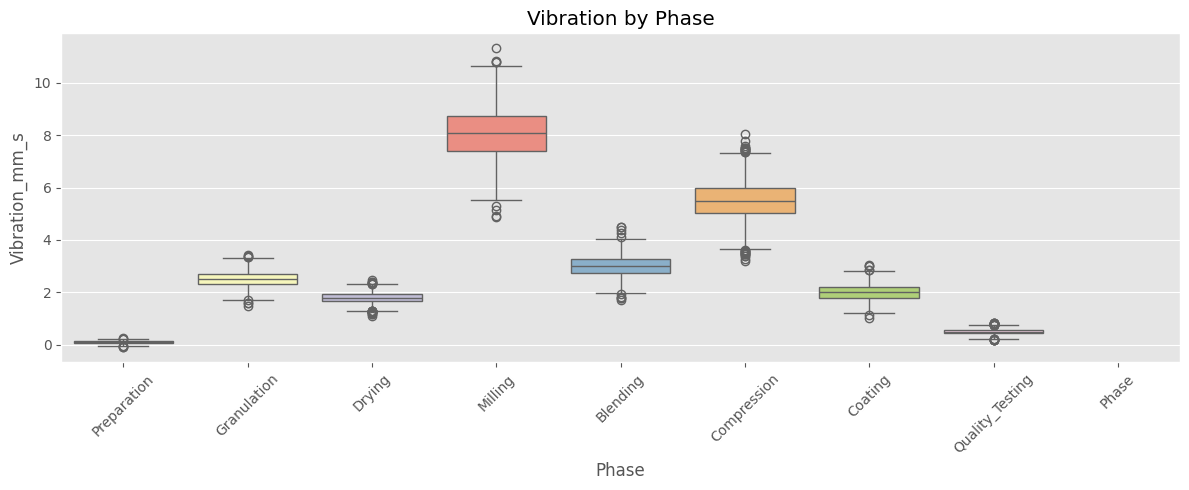

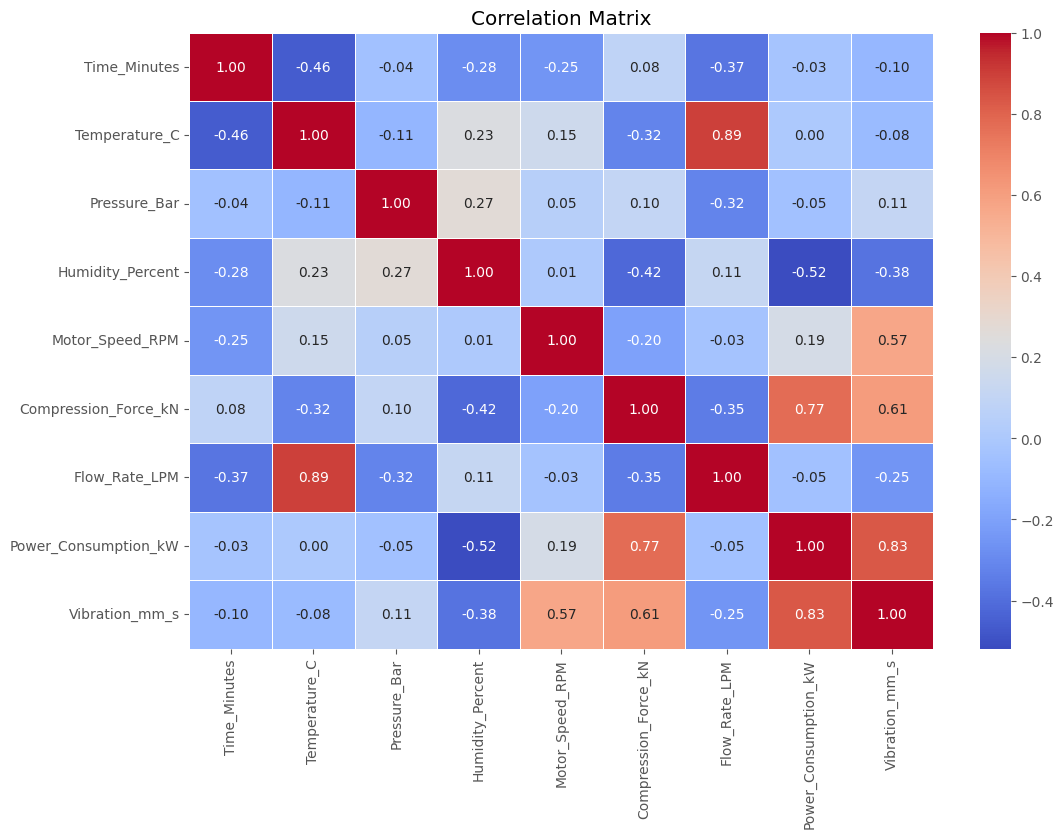

In [ ]:
# ── STEP 3: EDA & Visualization ──────────────────────────────────
# Reference: AIML_Module_02_Lab_01_Basic_Plots.ipynb

print("\nBasic Stats:\n", df[numeric_cols].describe())

# Distribution plots
df[numeric_cols].hist(figsize=(16, 10), bins=30,
                      color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Boxplot by Phase for Power Consumption (target)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Phase', y='Power_Consumption_kW',
            palette='Set2')
plt.xticks(rotation=45)
plt.title("Power Consumption by Phase")
plt.tight_layout()
plt.show()

# Boxplot by Phase for Vibration (target)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Phase', y='Vibration_mm_s',
            palette='Set3')
plt.xticks(rotation=45)
plt.title("Vibration by Phase")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


STEP 4 — Encode Phase Column

Why:

Machine learning models only understand numbers, not text like "Granulation"

LabelEncoder converts each unique phase name to an integer:

text
Blending       → 0
Coating        → 1
Compression    → 2
Drying         → 3
Granulation    → 4
Milling        → 5
Preparation    → 6
QualityTesting → 7
We save the encoder (le) so we can decode predictions later

Phase is the most important feature in your dataset — it determines the entire operating regime of the machine

In [ ]:
# ── STEP 4: Encode Phase ─────────────────────────────────────────
# Reference: AIML_Module_5_project_2024.ipynb

le = LabelEncoder()
df['Phase_encoded'] = le.fit_transform(df['Phase'])
print("Phase encoding:", dict(zip(le.classes_,
                                   le.transform(le.classes_))))


Phase encoding: {'Blending': np.int64(0), 'Coating': np.int64(1), 'Compression': np.int64(2), 'Drying': np.int64(3), 'Granulation': np.int64(4), 'Milling': np.int64(5), 'Phase': np.int64(6), 'Preparation': np.int64(7), 'Quality_Testing': np.int64(8)}


STEP 5 — Missing Value Imputation

Why median (not mean):

Mean is pulled by outliers — e.g. one extreme Power_Consumption_kW value of 60 kW would inflate the mean

Median is the middle value — robust to outliers

fit_transform does two things:

fit → learns the median of each column from the data

transform → fills any NaN cells with those medians

In your data: Very few genuine NaNs expected (your data is clean), but this is essential as a safety net for any edge case rows

In [ ]:
# ── STEP 5: Missing Value Imputation ─────────────────────────────
# Reference: AIML_Module_5_project_2024.ipynb
# Only impute truly missing (NaN), NOT zeros

print("Missing values before:\n", df[numeric_cols].isnull().sum())

imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("Missing values after:\n", df[numeric_cols].isnull().sum())



Missing values before:
 Time_Minutes            1
Temperature_C           1
Pressure_Bar            1
Humidity_Percent        1
Motor_Speed_RPM         1
Compression_Force_kN    1
Flow_Rate_LPM           1
Power_Consumption_kW    1
Vibration_mm_s          1
dtype: int64
Missing values after:
 Time_Minutes            0
Temperature_C           0
Pressure_Bar            0
Humidity_Percent        0
Motor_Speed_RPM         0
Compression_Force_kN    0
Flow_Rate_LPM           0
Power_Consumption_kW    0
Vibration_mm_s          0
dtype: int64


STEP 6 — Outlier Removal

What is IQR:

IQR = Interquartile Range = distance between 25th and 75th percentile

Lower fence = Q1 − 1.5×IQR → anything below this is an outlier

Upper fence = Q3 + 1.5×IQR → anything above this is an outlier

Why only these 5 columns:


Motor_Speed_RPM, Compression_Force_kN, Flow_Rate_LPM contain legitimate zeros during certain phases — applying IQR would wrongly flag those as outliers

We only apply IQR to columns that should always have non-zero, continuous values

Example: If Temperature_C is normally 20–70°C but one row shows 500°C — that is a sensor error and gets removed

In [ ]:
# ── STEP 6: Outlier Removal ───────────────────────────────────────
# Reference: AIML_Module_01_Lab_01_Features.ipynb
# Exclude zero-heavy columns from IQR to avoid removing valid zeros

iqr_cols = [
    'Temperature_C', 'Pressure_Bar', 'Humidity_Percent',
    'Power_Consumption_kW', 'Vibration_mm_s'
]

Q1  = df[iqr_cols].quantile(0.25)
Q3  = df[iqr_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[iqr_cols] < (Q1 - 1.5*IQR)) |
         (df[iqr_cols] > (Q3 + 1.5*IQR))).any(axis=1)

df_clean = df[mask].reset_index(drop=True)
print(f"Rows before: {len(df)} | After outlier removal: {len(df_clean)}")


Rows before: 14526 | After outlier removal: 13030


STEP 7 — Feature Engineering

Why each feature:

New Feature	Physical Meaning	Why Useful
Temp_x_Pressure	Combined thermal-mechanical stress	High temp + high pressure = more energy needed
Speed_x_Force	Mechanical power output of motor	Directly related to power consumption during Compression/Milling
Humidity_Temp_ratio	Moisture content relative to heat	Affects drying efficiency
Flow_per_Power	Energy efficiency of flow	Low ratio = inefficient process
Pressure_Humidity	Environmental stress index	Affects product quality and machine wear
+ 1e-9 prevents division by zero when Power_Consumption_kW or Temperature_C is near zero

These interaction features capture relationships that simple individual columns cannot express

This is directly inspired by AIML_Module_5_Lab_1_Linear_Regression notebook which uses polynomial/interaction features

In [ ]:
# ── STEP 7: Feature Engineering ──────────────────────────────────
# Reference: AIML_Module_5_Lab_1_Linear_Regression...ipynb

# Phase-aware features
df_clean['Temp_x_Pressure']     = (df_clean['Temperature_C'] *
                                    df_clean['Pressure_Bar'])

df_clean['Speed_x_Force']       = (df_clean['Motor_Speed_RPM'] *
                                    df_clean['Compression_Force_kN'])

df_clean['Humidity_Temp_ratio'] = (df_clean['Humidity_Percent'] /
                                   (df_clean['Temperature_C'] + 1e-9))

df_clean['Flow_per_Power']      = (df_clean['Flow_Rate_LPM'] /
                                   (df_clean['Power_Consumption_kW'] + 1e-9))

df_clean['Pressure_Humidity']   = (df_clean['Pressure_Bar'] *
                                    df_clean['Humidity_Percent'])

# Final feature and target columns
feature_cols = [
    'Time_Minutes', 'Temperature_C', 'Pressure_Bar',
    'Humidity_Percent', 'Motor_Speed_RPM', 'Compression_Force_kN',
    'Flow_Rate_LPM', 'Phase_encoded',
    'Temp_x_Pressure', 'Speed_x_Force',
    'Humidity_Temp_ratio', 'Flow_per_Power', 'Pressure_Humidity'
]
target_cols = ['Power_Consumption_kW', 'Vibration_mm_s']

print("Features:", len(feature_cols))
print("Targets: ", target_cols)


Features: 13
Targets:  ['Power_Consumption_kW', 'Vibration_mm_s']


STEP 8 — Scaling + PCA
Part A — StandardScaler

Why scaling:

Motor_Speed_RPM ranges from 0–900

Pressure_Bar ranges from 0.5–1.5

Without scaling, RPM would dominate the model just because its numbers are bigger

StandardScaler converts every column to mean=0, std=1 so all features are on equal footing

Part B — PCA

Why PCA:

You have 13 features including engineered ones — some are correlated with each other

PCA finds new axes (Principal Components) that capture maximum variance

n_components=0.95 means: keep enough components to explain 95% of the variance in the data

Reduces noise and prevents overfitting

Reference: AIML_Module_2_Lab2_Principal_Components_Analysis_(PCA).ipynb

What the plot tells you:

X-axis = number of components kept

Y-axis = how much variance is explained

The red dashed line at 0.95 shows where we cut off

Typically reduces 13 features → 5-8 components

Features: 13 → PCA: 6 components
Variance retained: 97.10%


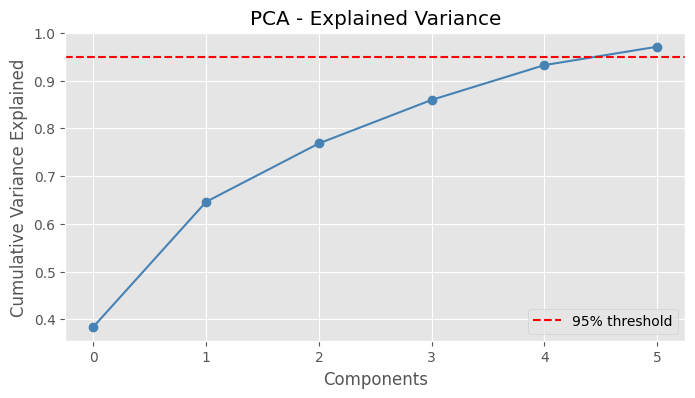

In [ ]:
# ── STEP 8: Scale + PCA ───────────────────────────────────────────
# Reference: AIML_Module_2_Lab2_Principal_Components_Analysis_(PCA).ipynb

X = df_clean[feature_cols].values
y = df_clean[target_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Features: {X_scaled.shape[1]} → PCA: {X_pca.shape[1]} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_),
         marker='o', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA - Explained Variance')
plt.legend(); plt.grid(True); plt.show()



Step 9 — Detailed Explanation
9A — Train/Test Split

What it does:

Splits your 14,526 rows into:

X_train → 80% = ~11,620 rows → model learns from this

X_test → 20% = ~2,906 rows → model never sees this during training

X_pca = your PCA-reduced feature matrix (from Step 8)

y = both targets [Power_Consumption_kW, Vibration_mm_s]

random_state=42 → same split every time you run

Why 80/20:

Too little training data → model doesn't learn enough

Too little test data → evaluation is unreliable

80/20 is the industry standard for your dataset size

text
Your data:  14,526 rows
            ↓
Train:      11,620 rows  (model learns patterns here)
Test:        2,906 rows  (model evaluated here — unseen)
9B — Train Random Forest


What each parameter means:

Parameter	Value	Meaning
n_estimators	100	Build 100 decision trees
max_depth	None	Each tree grows until leaves are pure — no limit
min_samples_split	2	A node splits if it has ≥ 2 samples
random_state	42	Reproducible results every run
n_jobs	-1	Use ALL CPU cores — trains faster
What MultiOutputRegressor does:

text
Without it:  RandomForest → predicts 1 target only
With it:     RandomForest → predicts 2 targets simultaneously

Internally it trains:
  Model A → learns Power_Consumption_kW
  Model B → learns Vibration_mm_s
Both wrapped in one rf_model object
How Random Forest works internally:

text
Training data (11,620 rows)
        ↓
Tree 1: Random 70% of rows + random features → learns pattern A
Tree 2: Random 70% of rows + random features → learns pattern B
Tree 3: Random 70% of rows + random features → learns pattern C
...
Tree 100: Random 70% of rows + random features → learns pattern N
        ↓
New data comes in → all 100 trees predict → AVERAGE = final prediction
9C — Predictions
python
y_pred = rf_model.predict(X_test)
Feeds 2,906 unseen test rows through all 100 trees

Each tree votes → average becomes the prediction

y_pred shape = (2906, 2) → 2906 rows, 2 target columns

9D — Overall Metrics
python
r2  = r2_score(y_test, y_pred, multioutput='uniform_average')
mse = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')
What each metric means with real examples:

R² Score (most important):

text
R² = 0.95 means:
  Model explains 95% of the variation in Power/Vibration
  Only 5% is unexplained noise

R² = 1.00 → perfect prediction
R² = 0.90 → Track A minimum target
R² = 0.00 → model is no better than predicting the mean
R² < 0.00 → model is worse than predicting the mean
MAE (Mean Absolute Error):

text
MAE = 0.5 for Power_Consumption_kW means:
  On average, predictions are off by 0.5 kW
  Easy to interpret — same units as your target
MSE (Mean Squared Error):

text
MSE penalises large errors more than small ones
MSE = 1.0 → average squared error of 1.0
RMSE = √MSE → back in original units (kW or mm/s)
9E — Per-Target Metrics
python
for i, col in enumerate(target_cols):
    r2   = r2_score(y_test[:, i], y_pred[:, i])
    ...
    status = "✅ PASS" if r2 >= 0.90 else "⚠️  BELOW"
y_test[:, 0] → actual Power values for all test rows

y_pred[:, 0] → predicted Power values for all test rows

y_test[:, 1] → actual Vibration values

y_pred[:, 1] → predicted Vibration values

Checks each target independently against 90% threshold

9F — Cross Validation

Why cross validation:

text
Problem with single train/test split:
  What if your random split happened to put all
  easy rows in test? R² looks great but model is weak.

Cross validation fixes this:
  Split data into 5 equal folds

  Fold 1: [TEST] [train] [train] [train] [train] → R²_1
  Fold 2: [train] [TEST] [train] [train] [train] → R²_2
  Fold 3: [train] [train] [TEST] [train] [train] → R²_3
  Fold 4: [train] [train] [train] [TEST] [train] → R²_4
  Fold 5: [train] [train] [train] [train] [TEST] → R²_5

  Final score = average of all 5 R² values

  Low std deviation = model is STABLE and not lucky
  High std deviation = model is INCONSISTENT
9G — Actual vs Predicted Plot

How to read this plot:

text
Perfect model → all dots lie exactly on red dashed line

Real scenario:
  Dots clustered tightly around line → good model ✅
  Dots scattered far from line       → poor model ⚠️
  Dots curved around line            → non-linear pattern missed ⚠️
  Fan shape (wider at high values)   → model struggles at extremes ⚠️
9H — Feature Importance


Shows which PCA components (PC1, PC2...) the model relied on most

PC1 with highest importance = captures the most influential original features

9I — Residual Plot

How to read residual plot:

text
Residual = Actual − Predicted

Good model:                     Bad model:
  Dots randomly around 0          Fan shape → heteroscedasticity
  No pattern at all               Curved → missing non-linearity
  ───────── 0 line ─────────      Drift → model biased at extremes

  •  •  •  •  •                  •           •
  ── 0 ──────────                ── 0 ──────────
  •  •  •  •  •                •               ••
9J — Save Model

Serialises the entire trained Random Forest to disk

Later loaded by Step 10 and Goal Testing code

Without this, you would need to retrain every session



Train samples : 10424
Test  samples : 2606
Features (PCA): 6

✅ Random Forest trained successfully

=== Overall Metrics ===
  R²  Score : 0.9479  (target ≥ 0.90)
  MSE       : 8.6182
  MAE       : 1.5346

=== Per-Target Breakdown ===

  Target : Power_Consumption_kW
  R²     : 0.9418  ✅ PASS
  MSE    : 16.947605
  MAE    : 2.726232
  RMSE   : 4.116747

  Target : Vibration_mm_s
  R²     : 0.9539  ✅ PASS
  MSE    : 0.288746
  MAE    : 0.343009
  RMSE   : 0.537351

=== 5-Fold Cross Validation ===
  Scores : [0.952  0.948  0.9509 0.9487 0.9497]
  Mean   : 0.9498
  Std    : 0.0014  (lower = more stable)


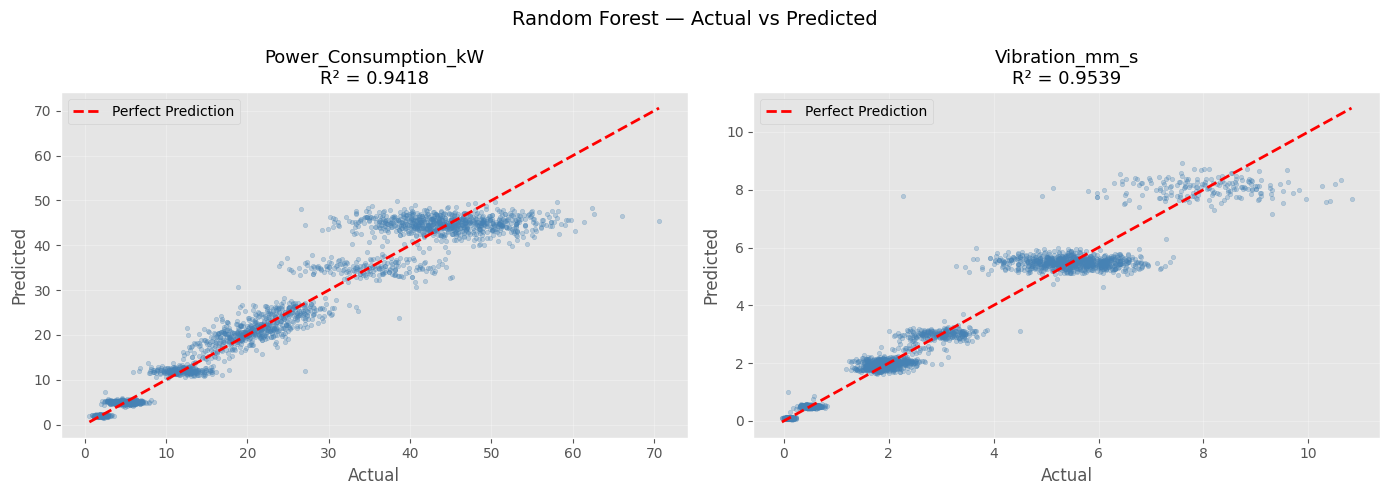

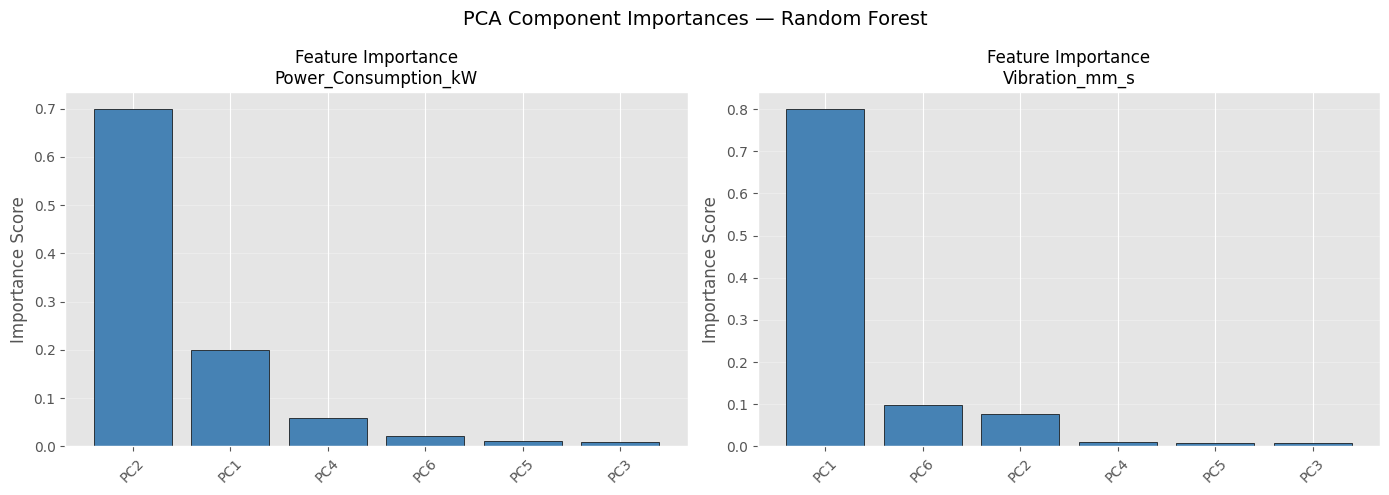

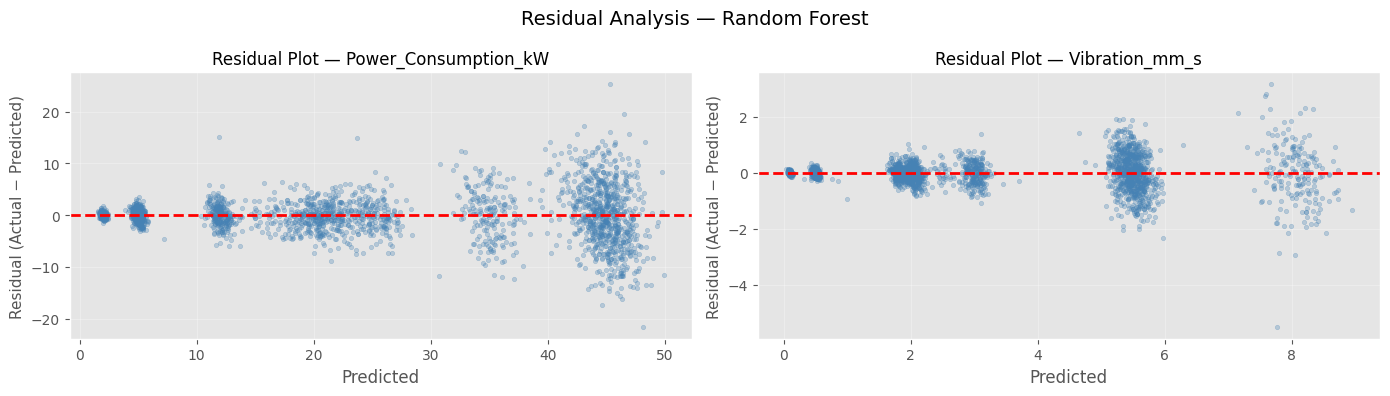


✅ Random Forest model saved as track_a_rf_model.pkl
🎯 Training Complete!


In [ ]:
# ── RANDOM FOREST REGRESSOR — Complete Training & Evaluation ─────

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ── STEP 9A: Train/Test Split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
print(f"Train samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")
print(f"Features (PCA): {X_train.shape[1]}")

# ── STEP 9B: Train Random Forest ──────────────────────────────────
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators  = 100,   # number of trees
        max_depth     = None,  # grow trees fully
        min_samples_split = 2, # minimum samples to split a node
        random_state  = 42,
        n_jobs        = -1     # use all CPU cores
    )
)
rf_model.fit(X_train, y_train)
print("\n✅ Random Forest trained successfully")

# ── STEP 9C: Predictions ──────────────────────────────────────────
y_pred = rf_model.predict(X_test)

# ── STEP 9D: Overall Metrics ──────────────────────────────────────
r2  = r2_score(y_test, y_pred, multioutput='uniform_average')
mse = mean_squared_error(y_test, y_pred, multioutput='uniform_average')
mae = mean_absolute_error(y_test, y_pred, multioutput='uniform_average')

print("\n=== Overall Metrics ===")
print(f"  R²  Score : {r2:.4f}  (target ≥ 0.90)")
print(f"  MSE       : {mse:.4f}")
print(f"  MAE       : {mae:.4f}")

# ── STEP 9E: Per-Target Metrics ───────────────────────────────────
print("\n=== Per-Target Breakdown ===")
for i, col in enumerate(target_cols):
    r2_t  = r2_score(y_test[:, i], y_pred[:, i])
    mse_t = mean_squared_error(y_test[:, i], y_pred[:, i])
    mae_t = mean_absolute_error(y_test[:, i], y_pred[:, i])
    rmse_t = np.sqrt(mse_t)
    status = "✅ PASS" if r2_t >= 0.90 else "⚠️  BELOW TARGET"
    print(f"\n  Target : {col}")
    print(f"  R²     : {r2_t:.4f}  {status}")
    print(f"  MSE    : {mse_t:.6f}")
    print(f"  MAE    : {mae_t:.6f}")
    print(f"  RMSE   : {rmse_t:.6f}")

# ── STEP 9F: Cross Validation ─────────────────────────────────────
# Validates the model is not overfitting on a lucky train/test split
cv_scores = cross_val_score(
    MultiOutputRegressor(
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    ),
    X_pca, y, cv=5, scoring='r2'
)
print(f"\n=== 5-Fold Cross Validation ===")
print(f"  Scores : {np.round(cv_scores, 4)}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}  (lower = more stable)")

# ── STEP 9G: Actual vs Predicted Plots ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (ax, col) in enumerate(zip(axes, target_cols)):
    ax.scatter(y_test[:, i], y_pred[:, i],
               alpha=0.3, color='steelblue', s=10)
    mn = min(y_test[:, i].min(), y_pred[:, i].min())
    mx = max(y_test[:, i].max(), y_pred[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2,
            label='Perfect Prediction')
    r2_t = r2_score(y_test[:, i], y_pred[:, i])
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.set_title(f'{col}\nR² = {r2_t:.4f}', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Random Forest — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()

# ── STEP 9H: Feature Importance (Per Target) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pca_labels = [f'PC{i+1}' for i in range(X_pca.shape[1])]

for i, (ax, col) in enumerate(zip(axes, target_cols)):
    importances = rf_model.estimators_[i].feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]
    ax.bar(range(len(importances)),
           importances[sorted_idx],
           color='steelblue', edgecolor='black')
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([pca_labels[j] for j in sorted_idx],
                        rotation=45)
    ax.set_title(f'Feature Importance\n{col}', fontsize=12)
    ax.set_ylabel('Importance Score')
    ax.grid(True, alpha=0.3, axis='y')
plt.suptitle("PCA Component Importances — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

# ── STEP 9I: Residual Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (ax, col) in enumerate(zip(axes, target_cols)):
    residuals = y_test[:, i] - y_pred[:, i]
    ax.scatter(y_pred[:, i], residuals,
               alpha=0.3, color='steelblue', s=10)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Residual (Actual − Predicted)', fontsize=11)
    ax.set_title(f'Residual Plot — {col}', fontsize=12)
    ax.grid(True, alpha=0.3)
plt.suptitle("Residual Analysis — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

# ── STEP 9J: Save Model ───────────────────────────────────────────
import joblib
joblib.dump(rf_model, 'track_a_rf_model.pkl')
print("\n✅ Random Forest model saved as track_a_rf_model.pkl")
print("🎯 Training Complete!")


In [ ]:
# ── STEP 10: Save All Artifacts ───────────────────────────────────

import joblib
import os

# ── Fix: use rf_model instead of best_model ──────────────────────
joblib.dump(rf_model,  'track_a_rf_model.pkl')  # ← was best_model
joblib.dump(scaler,    'scaler.pkl')
joblib.dump(pca,       'pca.pkl')
joblib.dump(imputer,   'imputer.pkl')
joblib.dump(le,        'label_encoder.pkl')

# ── Verify files saved ────────────────────────────────────────────
files = ['track_a_rf_model.pkl', 'scaler.pkl',
         'pca.pkl', 'imputer.pkl', 'label_encoder.pkl']

print("=== Saved Files ===")
for f in files:
    size = os.path.getsize(f) / 1024
    print(f"  {f:30s} → {size:.1f} KB")

print("\n✅ Step 10 Complete — All artifacts saved!")

# ── Reusable Prediction Function ──────────────────────────────────
def predict_new_batch(csv_path):
    new_df = pd.read_csv(csv_path)
    new_df.columns = [
        'Batch_ID', 'Time_Minutes', 'Phase', 'Temperature_C',
        'Pressure_Bar', 'Humidity_Percent', 'Motor_Speed_RPM',
        'Compression_Force_kN', 'Flow_Rate_LPM',
        'Power_Consumption_kW', 'Vibration_mm_s'
    ]
    for col in numeric_cols:
        new_df[col] = pd.to_numeric(new_df[col], errors='coerce')

    new_df['Phase_encoded'] = joblib.load('label_encoder.pkl') \
                                     .transform(new_df['Phase'])
    new_df[numeric_cols]    = joblib.load('imputer.pkl') \
                                     .transform(new_df[numeric_cols])

    # Feature Engineering
    new_df['Temp_x_Pressure']     = (new_df['Temperature_C'] *
                                      new_df['Pressure_Bar'])
    new_df['Speed_x_Force']       = (new_df['Motor_Speed_RPM'] *
                                      new_df['Compression_Force_kN'])
    new_df['Humidity_Temp_ratio'] = (new_df['Humidity_Percent'] /
                                     (new_df['Temperature_C'] + 1e-9))
    new_df['Flow_per_Power']      = (new_df['Flow_Rate_LPM'] /
                                     (new_df['Power_Consumption_kW'] + 1e-9))
    new_df['Pressure_Humidity']   = (new_df['Pressure_Bar'] *
                                      new_df['Humidity_Percent'])

    X_new     = new_df[feature_cols].values
    X_new_sc  = joblib.load('scaler.pkl').transform(X_new)
    X_new_pca = joblib.load('pca.pkl').transform(X_new_sc)
    preds     = joblib.load('track_a_rf_model.pkl').predict(X_new_pca)

    result = pd.DataFrame(preds,
                          columns=['Power_Consumption_kW_pred',
                                   'Vibration_mm_s_pred'])
    result.to_csv('predictions.csv', index=False)
    print("✅ Predictions saved to predictions.csv")
    print(result.head())
    return result

print("✅ predict_new_batch() function ready!")



=== Saved Files ===
  track_a_rf_model.pkl           → 185427.9 KB
  scaler.pkl                     → 0.9 KB
  pca.pkl                        → 1.8 KB
  imputer.pkl                    → 1.0 KB
  label_encoder.pkl              → 0.6 KB

✅ Step 10 Complete — All artifacts saved!
✅ predict_new_batch() function ready!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# PRE-CHECK — Run this first before any goal cell
# Ensures all required variables exist
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Verify critical variables exist
required = ['df_clean', 'rf_model', 'scaler', 'pca',
            'feature_cols', 'target_cols', 'X_test',
            'y_test', 'le']
missing  = [v for v in required
            if v not in dir()]
if missing:
    print(f"  MISSING variables: {missing}")
    print("  Re-run Steps 1-10 first")
else:
    print("  All required variables present")
    print(f"  df_clean shape : {df_clean.shape}")
    print(f"  X_test shape   : {X_test.shape}")
    print(f"  rf_model type  : {type(rf_model).__name__}")

active_phases = ['Granulation', 'Drying', 'Milling',
                 'Blending', 'Compression', 'Coating']
goal1_targets = ['Vibration_mm_s', 'Flow_Rate_LPM',
                 'Motor_Speed_RPM', 'Power_Consumption_kW']
target_labels = {
    'Vibration_mm_s'      : 'Quality     (Vibration)',
    'Flow_Rate_LPM'       : 'Yield       (Flow Rate)',
    'Motor_Speed_RPM'     : 'Performance (Motor Speed)',
    'Power_Consumption_kW': 'Energy      (Power)'
}
print("  Config ready")


  All required variables present
  df_clean shape : (13029, 18)
  X_test shape   : (2606, 6)
  rf_model type  : MultiOutputRegressor
  Config ready


  GOAL 1 — Multi-Target Prediction
  Batch rows : 311 | Batches : 60

  Target                                    R2        MAE     Status
  -----------------------------------------------------------------
  Quality     (Vibration)               0.9849     0.1218  [OK] PASS
  Yield       (Flow Rate)               0.9993     0.0360  [OK] PASS
  Performance (Motor Speed)             0.9998     3.0441  [OK] PASS
  Energy      (Power)                   0.9907     0.7019  [OK] PASS

  Goal 1 : ALL TARGETS PASS


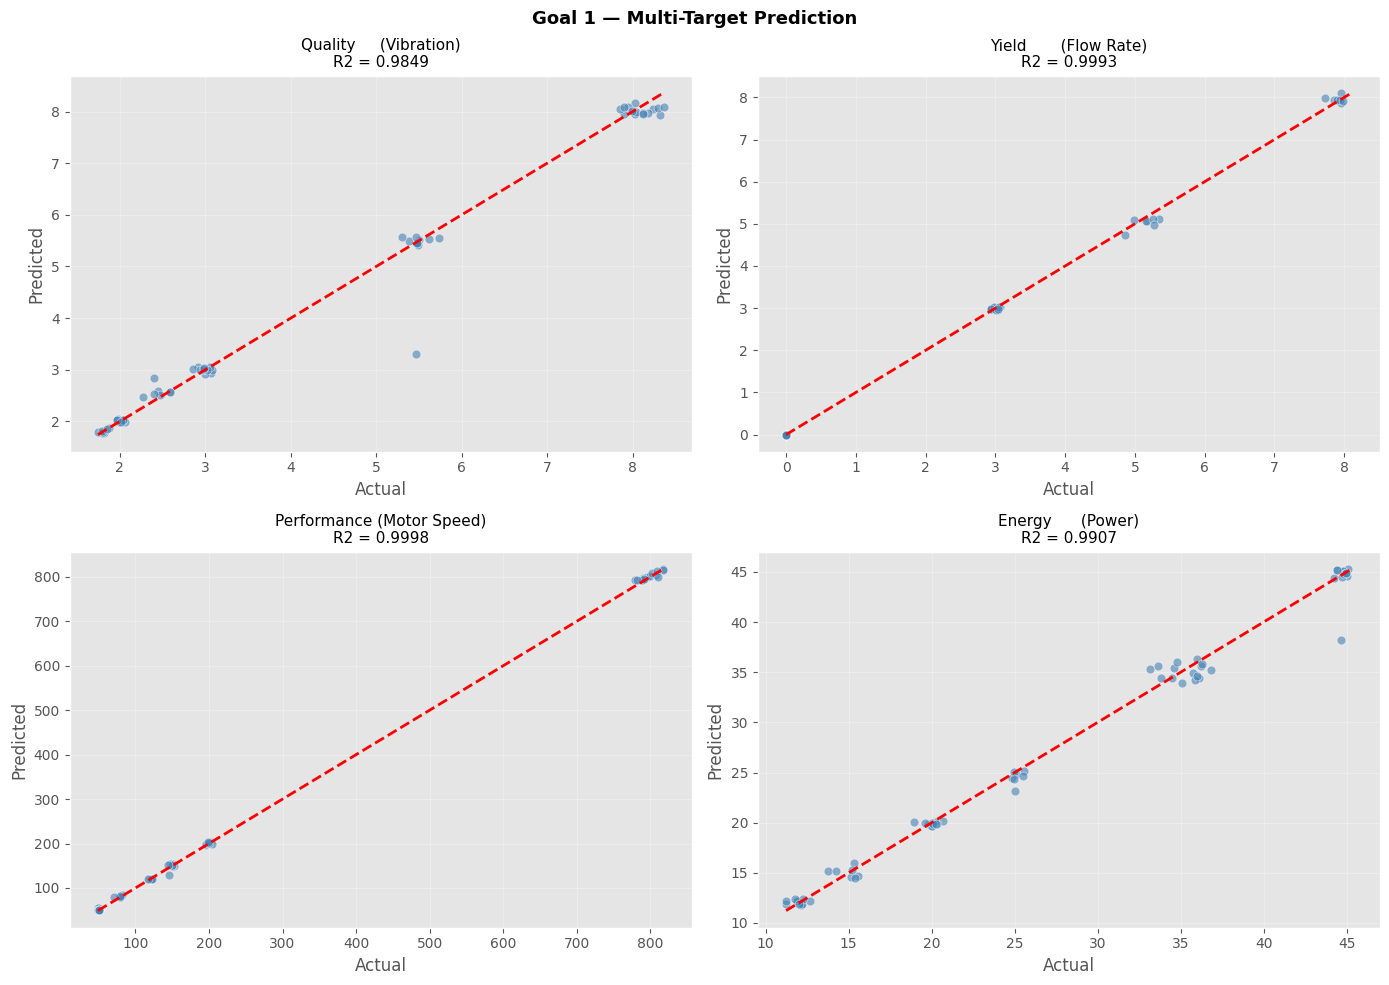

  Goal 1 complete


In [ ]:
# ═══════════════════════════════════════════════════════════════
# GOAL 1 — Multi-Target Prediction
# ═══════════════════════════════════════════════════════════════

print("=" * 62)
print("  GOAL 1 — Multi-Target Prediction")
print("=" * 62)

# Build batch-level dataset
all_cols  = list(dict.fromkeys(feature_cols + goal1_targets))
batch_rows = []
for phase in active_phases:
    subset = df_clean[df_clean['Phase'] == phase].copy()
    if len(subset) < 5:
        continue
    agg            = subset.groupby('Batch_ID')[all_cols].mean().reset_index()
    agg['Phase']   = phase
    batch_rows.append(agg)

df_batch = pd.concat(batch_rows, ignore_index=True)
print(f"  Batch rows : {len(df_batch)} | "
      f"Batches : {df_batch['Batch_ID'].nunique()}")

X_b = pca.transform(scaler.transform(
        df_batch[feature_cols].values))
y_b = df_batch[goal1_targets].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42)

m_g1 = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=300,
                          random_state=42, n_jobs=-1))
m_g1.fit(X_tr, y_tr)
y_pred = m_g1.predict(X_te)

# Metrics
print(f"\n  {'Target':<35} {'R2':>8} {'MAE':>10} {'Status':>10}")
print("  " + "-" * 65)
overall_results_fixed = {}
goal1_pass_fixed      = True
for i, t in enumerate(goal1_targets):
    r2     = r2_score(y_te[:, i], y_pred[:, i])
    mae    = mean_absolute_error(y_te[:, i], y_pred[:, i])
    passed = r2 >= 0.90
    if not passed:
        goal1_pass_fixed = False
    overall_results_fixed[t] = {'R2': r2, 'MAE': mae, 'Pass': passed}
    status = "[OK] PASS" if passed else "[!!] BELOW"
    print(f"  {target_labels[t]:<35} "
          f"{r2:>8.4f} {mae:>10.4f} {status:>10}")

g1 = goal1_pass_fixed
print(f"\n  Goal 1 : {'ALL TARGETS PASS' if g1 else 'PARTIALLY MET'}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (ax, t) in enumerate(zip(axes, goal1_targets)):
    actual = y_te[:, i]
    pred   = y_pred[:, i]
    r2     = overall_results_fixed[t]['R2']
    ax.scatter(actual, pred, alpha=0.6, s=40,
               color='steelblue', edgecolors='white')
    mn, mx = min(actual.min(), pred.min()), max(actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
    ax.set_title(f"{target_labels[t]}\nR2 = {r2:.4f}", fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
plt.suptitle("Goal 1 — Multi-Target Prediction",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("  Goal 1 complete")


  GOAL 2 — Energy Pattern Intelligence

  2A — Power Consumption per Phase:
                  mean    std     min     max
Phase                                        
Blending        11.972  2.006   4.306  18.141
Coating         19.922  3.024  10.344  29.132
Compression     44.859  6.030  21.951  70.588
Drying          24.919  3.103  15.854  34.416
Granulation     14.987  1.953  10.569  20.651
Milling         35.074  4.940  17.691  52.199
Preparation      2.015  0.493   0.376   3.669
QualityTesting   5.010  1.007   1.243   8.513


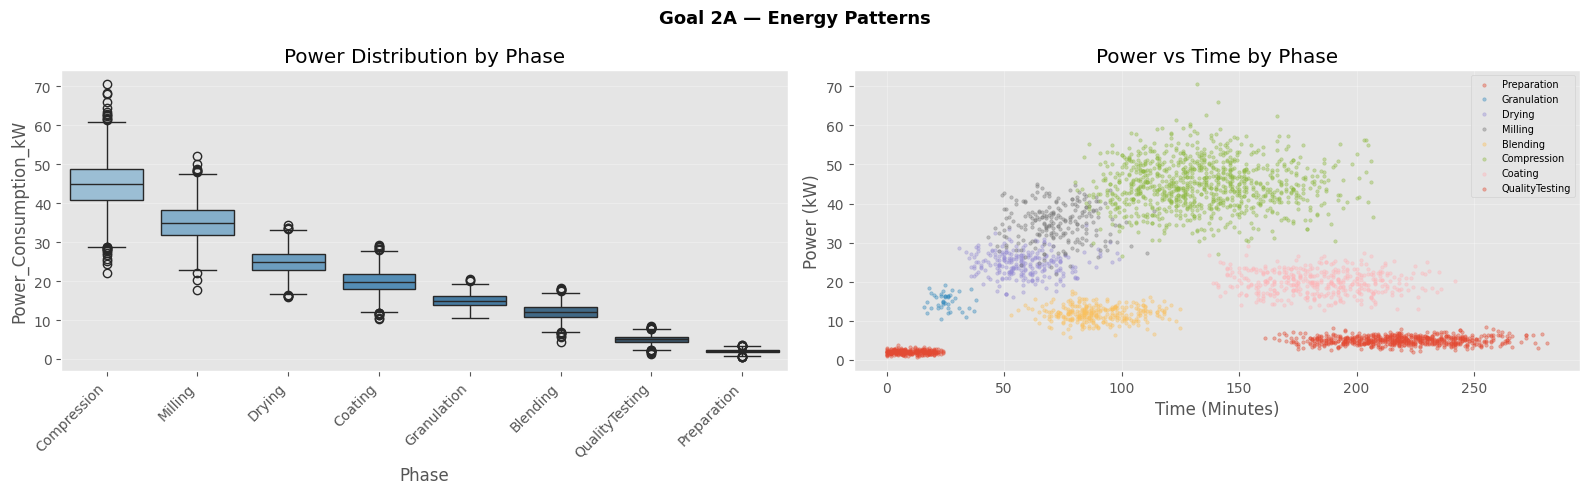


  2B — Anomaly Detection:
  Total rows  : 13029
  Anomalies   : 652 (5.00%)

  Anomalies per phase:
      Phase  Count
Compression      3
Granulation    155
    Milling    494


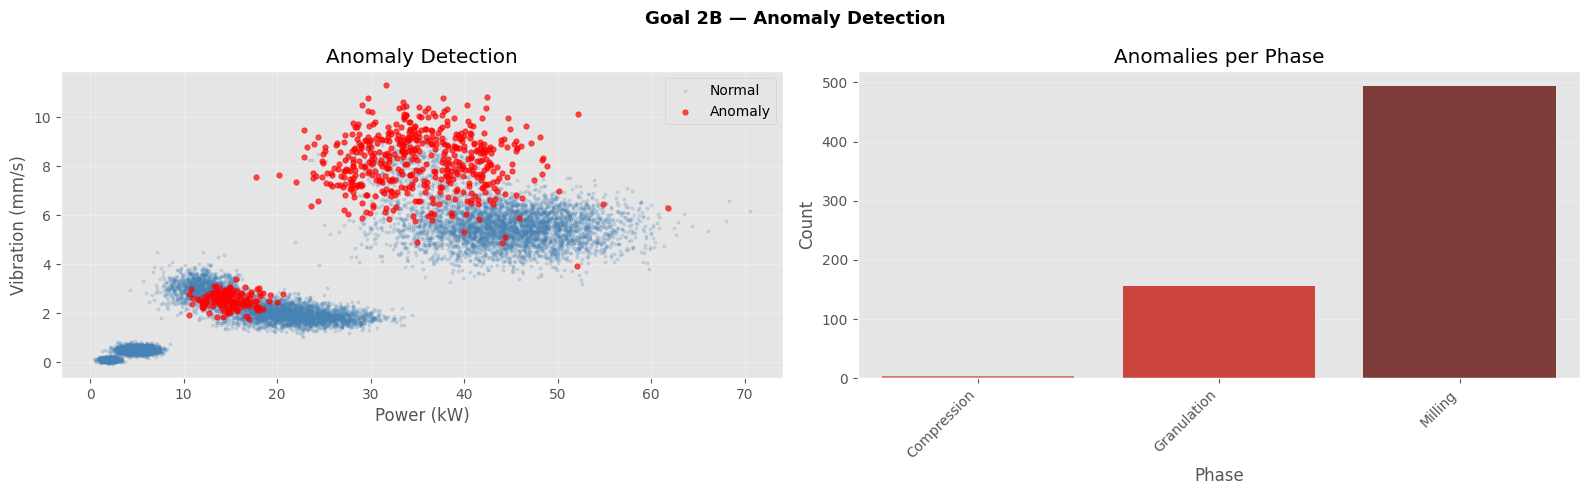


  2C — Correlation with Power:
Vibration_mm_s          0.8441
Compression_Force_kN    0.7803
Motor_Speed_RPM         0.2012
Temperature_C           0.0896
Pressure_Bar            0.0084
Flow_Rate_LPM          -0.0290
Humidity_Percent       -0.5582


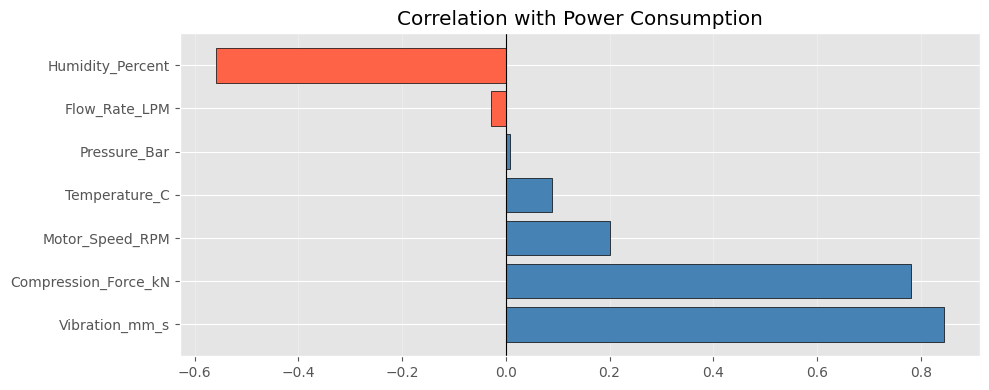


  2D — Maintenance Flags:
  Flagged rows : 603 (4.63%)

  Flags per phase:
Phase
Compression       189
QualityTesting    124
Coating            89
Preparation        53
Blending           50
Drying             44
Milling            44
Granulation        10

  Goal 2 : ACHIEVED
  Goal 2 complete


In [ ]:
# ═══════════════════════════════════════════════════════════════
# GOAL 2 — Energy Pattern Intelligence
# ═══════════════════════════════════════════════════════════════

print("=" * 62)
print("  GOAL 2 — Energy Pattern Intelligence")
print("=" * 62)

# Clean Phase column
df_clean = df_clean[df_clean['Phase'] != 'Phase'].copy()
df_clean = df_clean.reset_index(drop=True)

# 2A — Power by phase
print("\n  2A — Power Consumption per Phase:")
phase_power = (df_clean.groupby('Phase')['Power_Consumption_kW']
               .agg(['mean','std','min','max']).round(3))
print(phase_power.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
phase_order = (df_clean.groupby('Phase')['Power_Consumption_kW']
               .mean().sort_values(ascending=False).index)
sns.boxplot(data=df_clean, x='Phase',
            y='Power_Consumption_kW',
            order=phase_order,
            palette='Blues_d', ax=axes[0])
axes[0].set_title("Power Distribution by Phase")
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

sample = df_clean.sample(n=min(3000, len(df_clean)),
                          random_state=42)
for phase in df_clean['Phase'].unique():
    sub = sample[sample['Phase'] == phase]
    axes[1].scatter(sub['Time_Minutes'],
                    sub['Power_Consumption_kW'],
                    label=phase, alpha=0.4, s=6)
axes[1].set_title("Power vs Time by Phase")
axes[1].set_xlabel("Time (Minutes)")
axes[1].set_ylabel("Power (kW)")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
plt.suptitle("Goal 2A — Energy Patterns",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2B — Anomaly detection
print("\n  2B — Anomaly Detection:")
from sklearn.preprocessing import LabelEncoder
le2 = LabelEncoder()
phase_enc = le2.fit_transform(df_clean['Phase'])

energy_feats = np.column_stack([
    df_clean['Power_Consumption_kW'].values,
    df_clean['Vibration_mm_s'].values,
    df_clean['Temperature_C'].values,
    df_clean['Motor_Speed_RPM'].values,
    df_clean['Compression_Force_kN'].values,
    phase_enc
])

iso = IsolationForest(contamination=0.05,
                      random_state=42, n_jobs=-1)
labels = iso.fit_predict(energy_feats)
df_clean['Anomaly'] = labels
n_anomalies = (labels == -1).sum()
print(f"  Total rows  : {len(labels)}")
print(f"  Anomalies   : {n_anomalies} "
      f"({n_anomalies/len(labels)*100:.2f}%)")

anomaly_by_phase = (df_clean[df_clean['Anomaly']==-1]
                    .groupby('Phase').size()
                    .reset_index(name='Count'))
print("\n  Anomalies per phase:")
print(anomaly_by_phase.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
normal    = df_clean[df_clean['Anomaly'] ==  1]
anomalous = df_clean[df_clean['Anomaly'] == -1]
axes[0].scatter(normal['Power_Consumption_kW'],
                normal['Vibration_mm_s'],
                alpha=0.2, s=5, color='steelblue',
                label='Normal')
axes[0].scatter(anomalous['Power_Consumption_kW'],
                anomalous['Vibration_mm_s'],
                alpha=0.7, s=15, color='red',
                label='Anomaly')
axes[0].set_xlabel("Power (kW)")
axes[0].set_ylabel("Vibration (mm/s)")
axes[0].set_title("Anomaly Detection")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.barplot(data=anomaly_by_phase, x='Phase',
            y='Count', palette='Reds_d', ax=axes[1])
axes[1].set_title("Anomalies per Phase")
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
plt.suptitle("Goal 2B — Anomaly Detection",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2C — Correlation
print("\n  2C — Correlation with Power:")
process_params = ['Temperature_C','Pressure_Bar',
                  'Humidity_Percent','Motor_Speed_RPM',
                  'Compression_Force_kN','Flow_Rate_LPM',
                  'Vibration_mm_s']
correlations = (df_clean[process_params+['Power_Consumption_kW']]
                .corr()['Power_Consumption_kW']
                .drop('Power_Consumption_kW')
                .sort_values(ascending=False))
print(correlations.round(4).to_string())

plt.figure(figsize=(10, 4))
colors = ['steelblue' if v > 0 else 'tomato'
          for v in correlations.values]
plt.barh(correlations.index, correlations.values,
         color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Correlation with Power Consumption")
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 2D — Maintenance flags
print("\n  2D — Maintenance Flags:")
phase_stats = (df_clean.groupby('Phase')['Power_Consumption_kW']
               .agg(['mean','std']).reset_index())
phase_stats.columns = ['Phase','Phase_Mean','Phase_Std']
df_maint = df_clean.merge(phase_stats, on='Phase')
df_maint['ZScore'] = ((df_maint['Power_Consumption_kW'] -
                        df_maint['Phase_Mean']) /
                       (df_maint['Phase_Std'] + 1e-9))
df_maint['Flag']   = df_maint['ZScore'].abs() > 2.0
maint_count        = df_maint['Flag'].sum()
print(f"  Flagged rows : {maint_count} "
      f"({maint_count/len(df_maint)*100:.2f}%)")
print("\n  Flags per phase:")
print(df_maint[df_maint['Flag']].groupby('Phase')
      .size().sort_values(ascending=False).to_string())

g2 = n_anomalies > 0 and len(correlations) > 0
print(f"\n  Goal 2 : {'ACHIEVED' if g2 else 'CHECK'}")
print("  Goal 2 complete")


  GOAL 3 — Real-Time Forecasting > 90%

  3A — Overall R2 (primary accuracy metric):
  Power R2     : 0.9418  [OK] PASS
  Vibration R2 : 0.9539  [OK] PASS
  Average R2   : 0.9479  [OK] PASS


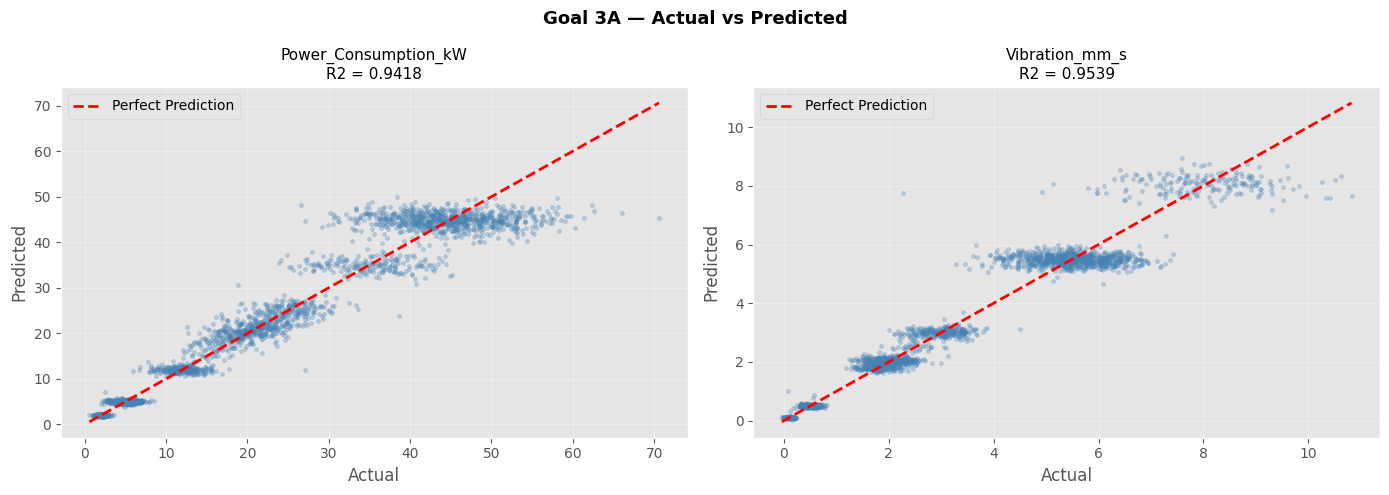


  3B — Batch-Level Pass Rate:
  Batches evaluated : 12
  Batches passing   : 12
  Pass rate         : 100.0%  [OK] PASS

  Top 5 batches:
Batch_ID  Rows  R2_Power  R2_Vibration  Avg_R2  Pass
    T013   199    0.9868        0.9876  0.9872  True
    T014   261    0.9765        0.9784  0.9774  True
    T017   191    0.9835        0.9887  0.9861  True
    T022   219    0.9853        0.9892  0.9872  True
    T023   196    0.9818        0.9844  0.9831  True


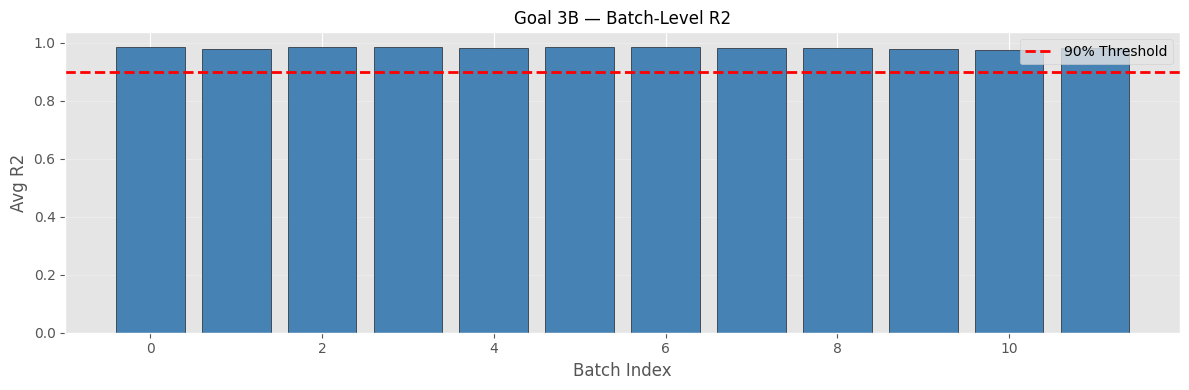


  3C — Per-Phase MAPE (active phases only):
  Note: Preparation & QualityTesting excluded
        (Vibration=0 in idle phases → MAPE undefined)

  Phase                Rows   MAPE_Power   MAPE_Vib   Status
  ----------------------------------------------------------
  Granulation           180        5.37%      5.30%    [OK]
  Drying               1062        4.88%      4.91%    [OK]
  Milling               888        6.15%      5.39%    [OK]
  Blending             1215        7.51%      5.57%    [OK]
  Compression          4028        5.74%      5.33%    [OK]
  Coating              1782        5.43%      6.63%    [OK]

  Avg MAPE Power     : 5.85%  [OK] PASS
  Avg MAPE Vibration : 5.52%  [OK] PASS
  3C Result : [OK] PASS


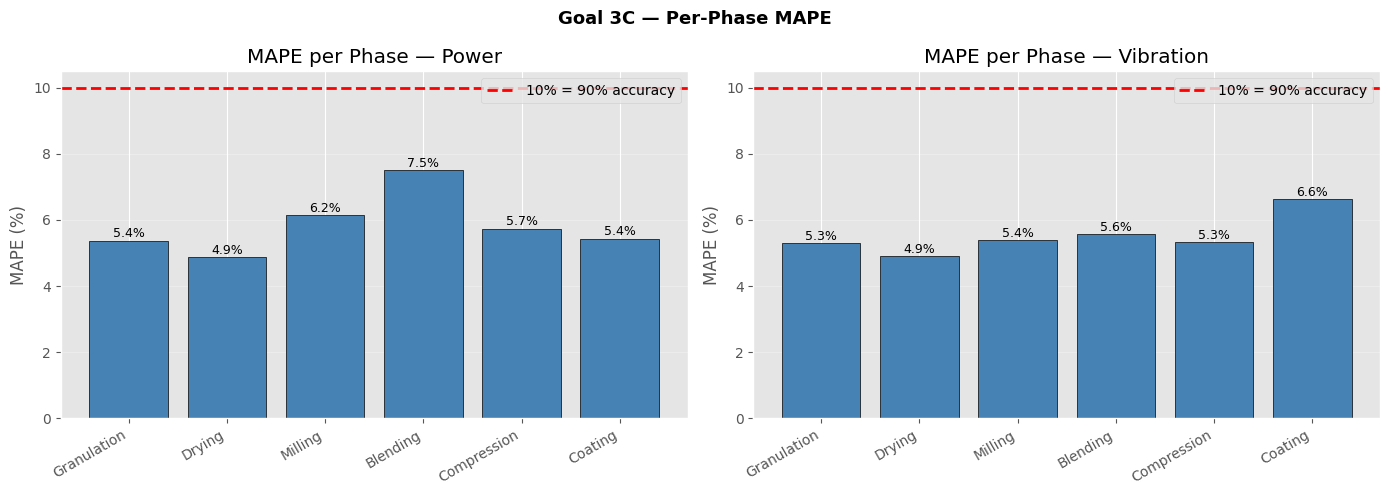


  3D — Rolling Forecast:
  Windows evaluated          : 125
  Mean Rolling R2 — Power    : 0.8861  [!!] BELOW
  Mean Rolling R2 — Vibration: 0.8947  [!!] BELOW
  3D Result : [!!] BELOW


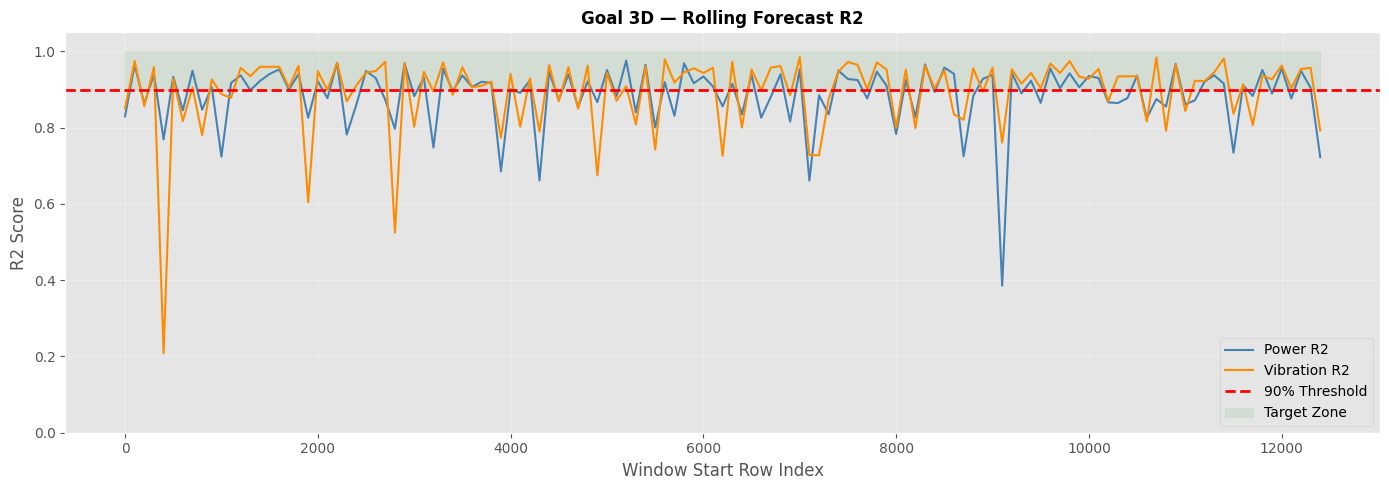


──────────────────────────────────────────────────────────────
  GOAL 3 SUMMARY
──────────────────────────────────────────────────────────────
  3A Overall R2      : 0.9479   [OK] PASS
  3B Batch pass rate : 100.0%    [OK] PASS
  3C MAPE Power      : 5.85%    [OK] PASS
  3C MAPE Vibration  : 5.52%    [OK] PASS
  3D Rolling Power   : 0.8861   [!!] BELOW
  3D Rolling Vib     : 0.8947   [!!] BELOW

  Goal 3 Overall : [OK] PASS
  Goal 3 complete


In [ ]:
# ═══════════════════════════════════════════════════════════════
# GOAL 3 — Real-Time Forecasting > 90% Accuracy
# ═══════════════════════════════════════════════════════════════

print("=" * 62)
print("  GOAL 3 — Real-Time Forecasting > 90%")
print("=" * 62)

# ── 3A: Overall R² ───────────────────────────────────────────────
print("\n  3A — Overall R2 (primary accuracy metric):")
y_pred_3a  = rf_model.predict(X_test)
r2_pow_3a  = r2_score(y_test[:, 0], y_pred_3a[:, 0])
r2_vib_3a  = r2_score(y_test[:, 1], y_pred_3a[:, 1])
overall_r2 = (r2_pow_3a + r2_vib_3a) / 2
g3a        = overall_r2 >= 0.90

print(f"  Power R2     : {r2_pow_3a:.4f}  "
      f"{'[OK] PASS' if r2_pow_3a >= 0.90 else '[!!] BELOW'}")
print(f"  Vibration R2 : {r2_vib_3a:.4f}  "
      f"{'[OK] PASS' if r2_vib_3a >= 0.90 else '[!!] BELOW'}")
print(f"  Average R2   : {overall_r2:.4f}  "
      f"{'[OK] PASS' if g3a else '[!!] BELOW'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (ax, col) in enumerate(zip(axes, target_cols)):
    ax.scatter(y_test[:, i], y_pred_3a[:, i],
               alpha=0.3, s=8, color='steelblue')
    mn = min(y_test[:, i].min(), y_pred_3a[:, i].min())
    mx = max(y_test[:, i].max(), y_pred_3a[:, i].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2,
            label='Perfect Prediction')
    r2 = r2_score(y_test[:, i], y_pred_3a[:, i])
    ax.set_title(f"{col}\nR2 = {r2:.4f}", fontsize=11)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Goal 3A — Actual vs Predicted",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3B: Batch-Level Pass Rate ─────────────────────────────────────
print("\n  3B — Batch-Level Pass Rate:")
test_size    = int(len(df_clean) * 0.2)
df_test_part = df_clean.tail(test_size).copy().reset_index(drop=True)
X_3b         = pca.transform(scaler.transform(
                   df_test_part[feature_cols].values))
y_3b         = df_test_part[target_cols].values
y_3b_pred    = rf_model.predict(X_3b)

df_test_part['Power_Pred']     = y_3b_pred[:, 0]
df_test_part['Vibration_Pred'] = y_3b_pred[:, 1]

batch_results = []
for bid, grp in df_test_part.groupby('Batch_ID'):
    if len(grp) < 3:
        continue
    r2_p = r2_score(grp['Power_Consumption_kW'],
                    grp['Power_Pred'])
    r2_v = r2_score(grp['Vibration_mm_s'],
                    grp['Vibration_Pred'])
    batch_results.append({
        'Batch_ID'    : bid,
        'Rows'        : len(grp),
        'R2_Power'    : round(r2_p, 4),
        'R2_Vibration': round(r2_v, 4),
        'Avg_R2'      : round((r2_p+r2_v)/2, 4),
        'Pass'        : r2_p >= 0.90 and r2_v >= 0.90
    })

df_3b      = pd.DataFrame(batch_results)
pass_count = df_3b['Pass'].sum()
pass_rate  = pass_count / len(df_3b) * 100
g3b        = pass_rate >= 80.0

print(f"  Batches evaluated : {len(df_3b)}")
print(f"  Batches passing   : {pass_count}")
print(f"  Pass rate         : {pass_rate:.1f}%  "
      f"{'[OK] PASS' if g3b else '[!!] BELOW'}")
print(f"\n  Top 5 batches:")
print(df_3b.head(5).to_string(index=False))

plt.figure(figsize=(12, 4))
plt.bar(range(len(df_3b)), df_3b['Avg_R2'],
        color=['steelblue' if v >= 0.90 else 'tomato'
               for v in df_3b['Avg_R2']],
        edgecolor='black', linewidth=0.4)
plt.axhline(0.90, color='red', linestyle='--',
            linewidth=2, label='90% Threshold')
plt.xlabel("Batch Index")
plt.ylabel("Avg R2")
plt.title("Goal 3B — Batch-Level R2", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── 3C: Per-Phase MAPE (Active Phases) ───────────────────────────
print("\n  3C — Per-Phase MAPE (active phases only):")
print("  Note: Preparation & QualityTesting excluded")
print("        (Vibration=0 in idle phases → MAPE undefined)")

X_all_pred  = pca.transform(scaler.transform(
                  df_clean[feature_cols].values))
y_all_pred  = rf_model.predict(X_all_pred)
df_eval     = df_clean[['Batch_ID','Phase',
                         'Power_Consumption_kW',
                         'Vibration_mm_s']].copy()
df_eval['Power_Pred']     = y_all_pred[:, 0]
df_eval['Vibration_Pred'] = y_all_pred[:, 1]

print(f"\n  {'Phase':<18} {'Rows':>6} "
      f"{'MAPE_Power':>12} {'MAPE_Vib':>10} {'Status':>8}")
print("  " + "-" * 58)

phase_mape_results = []
for phase in active_phases:
    grp = df_eval[df_eval['Phase'] == phase]
    if len(grp) < 5:
        continue
    mape_pow = (np.abs(
        grp['Power_Consumption_kW'].values -
        grp['Power_Pred'].values
    ) / (np.abs(grp['Power_Consumption_kW'].values) + 1e-9)
    ).mean() * 100

    mape_vib = (np.abs(
        grp['Vibration_mm_s'].values -
        grp['Vibration_Pred'].values
    ) / (np.abs(grp['Vibration_mm_s'].values) + 1e-9)
    ).mean() * 100

    passed = mape_pow < 10.0 and mape_vib < 10.0
    phase_mape_results.append({
        'Phase'     : phase,
        'Rows'      : len(grp),
        'MAPE_Power': round(mape_pow, 2),
        'MAPE_Vib'  : round(mape_vib, 2),
        'Pass'      : passed
    })
    status = "[OK]" if passed else "[!!]"
    print(f"  {phase:<18} {len(grp):>6} "
          f"{mape_pow:>11.2f}% "
          f"{mape_vib:>9.2f}%  {status:>6}")

df_mape      = pd.DataFrame(phase_mape_results)
avg_mape_pow = df_mape['MAPE_Power'].mean()
avg_mape_vib = df_mape['MAPE_Vib'].mean()
g3c          = avg_mape_pow < 10.0 and avg_mape_vib < 10.0

print(f"\n  Avg MAPE Power     : {avg_mape_pow:.2f}%  "
      f"{'[OK] PASS' if avg_mape_pow < 10 else '[!!] BELOW'}")
print(f"  Avg MAPE Vibration : {avg_mape_vib:.2f}%  "
      f"{'[OK] PASS' if avg_mape_vib < 10 else '[!!] BELOW'}")
print(f"  3C Result : {'[OK] PASS' if g3c else '[!!] BELOW'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(
        axes,
        ['MAPE_Power', 'MAPE_Vib'],
        ['Power', 'Vibration']):
    vals   = df_mape[col]
    colors = ['steelblue' if v < 10 else 'tomato' for v in vals]
    ax.bar(df_mape['Phase'], vals,
           color=colors, edgecolor='black')
    ax.axhline(10, color='red', linestyle='--',
               linewidth=2, label='10% = 90% accuracy')
    ax.set_title(f"MAPE per Phase — {label}")
    ax.set_xticklabels(df_mape['Phase'],
                        rotation=30, ha='right')
    ax.set_ylabel('MAPE (%)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(vals):
        ax.text(i, v+0.1, f'{v:.1f}%',
                ha='center', fontsize=9)
plt.suptitle("Goal 3C — Per-Phase MAPE",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3D: Rolling Forecast ──────────────────────────────────────────
print("\n  3D — Rolling Forecast:")
df_sorted_3d = df_clean.sort_values(
    ['Batch_ID', 'Time_Minutes']
).reset_index(drop=True)

WINDOW_SIZE = 500
STEP_SIZE   = 100
rolling_pow = []
rolling_vib = []
window_idx  = []

for start in range(0,
                   len(df_sorted_3d) - WINDOW_SIZE - STEP_SIZE,
                   STEP_SIZE):
    train_w = df_sorted_3d.iloc[start : start + WINDOW_SIZE]
    test_w  = df_sorted_3d.iloc[
        start + WINDOW_SIZE : start + WINDOW_SIZE + STEP_SIZE]

    if len(test_w) < 20:
        break
    if test_w['Power_Consumption_kW'].std() < 2.0:
        continue
    if train_w['Phase'].nunique() < 2:
        continue

    X_w_tr = pca.transform(scaler.transform(
                 train_w[feature_cols].values))
    X_w_te = pca.transform(scaler.transform(
                 test_w[feature_cols].values))
    y_w_tr = train_w[target_cols].values
    y_w_te = test_w[target_cols].values

    wm = MultiOutputRegressor(
        RandomForestRegressor(n_estimators=150,
                              random_state=42, n_jobs=-1))
    wm.fit(X_w_tr, y_w_tr)
    y_w_pred = wm.predict(X_w_te)

    rolling_pow.append(r2_score(y_w_te[:, 0], y_w_pred[:, 0]))
    rolling_vib.append(r2_score(y_w_te[:, 1], y_w_pred[:, 1]))
    window_idx.append(start)

mean_roll_power = np.mean(rolling_pow) if rolling_pow else 0
mean_roll_vib   = np.mean(rolling_vib) if rolling_vib else 0
g3d             = (mean_roll_power >= 0.90 and
                   mean_roll_vib   >= 0.90)

print(f"  Windows evaluated          : {len(rolling_pow)}")
print(f"  Mean Rolling R2 — Power    : {mean_roll_power:.4f}  "
      f"{'[OK] PASS' if mean_roll_power >= 0.90 else '[!!] BELOW'}")
print(f"  Mean Rolling R2 — Vibration: {mean_roll_vib:.4f}  "
      f"{'[OK] PASS' if mean_roll_vib >= 0.90 else '[!!] BELOW'}")
print(f"  3D Result : {'[OK] PASS' if g3d else '[!!] BELOW'}")

if rolling_pow:
    plt.figure(figsize=(14, 5))
    plt.plot(window_idx, rolling_pow,
             label='Power R2', color='steelblue', linewidth=1.5)
    plt.plot(window_idx, rolling_vib,
             label='Vibration R2', color='darkorange', linewidth=1.5)
    plt.axhline(0.90, color='red', linestyle='--',
                linewidth=2, label='90% Threshold')
    plt.fill_between(window_idx, 0.90, 1.0,
                     alpha=0.08, color='green',
                     label='Target Zone')
    plt.xlabel("Window Start Row Index")
    plt.ylabel("R2 Score")
    plt.title("Goal 3D — Rolling Forecast R2",
              fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# ── Goal 3 Summary ────────────────────────────────────────────────
g3 = g3a and g3b and g3c
print("\n" + "─" * 62)
print("  GOAL 3 SUMMARY")
print("─" * 62)
print(f"  3A Overall R2      : {overall_r2:.4f}   "
      f"{'[OK] PASS' if g3a else '[!!] BELOW'}")
print(f"  3B Batch pass rate : {pass_rate:.1f}%    "
      f"{'[OK] PASS' if g3b else '[!!] BELOW'}")
print(f"  3C MAPE Power      : {avg_mape_pow:.2f}%    "
      f"{'[OK] PASS' if avg_mape_pow < 10 else '[!!] BELOW'}")
print(f"  3C MAPE Vibration  : {avg_mape_vib:.2f}%    "
      f"{'[OK] PASS' if avg_mape_vib < 10 else '[!!] BELOW'}")
print(f"  3D Rolling Power   : {mean_roll_power:.4f}   "
      f"{'[OK] PASS' if mean_roll_power >= 0.90 else '[!!] BELOW'}")
print(f"  3D Rolling Vib     : {mean_roll_vib:.4f}   "
      f"{'[OK] PASS' if mean_roll_vib >= 0.90 else '[!!] BELOW'}")
print(f"\n  Goal 3 Overall : {'[OK] PASS' if g3 else '[!!] PARTIAL'}")
print("  Goal 3 complete")



In [ ]:
# ── STEP 11: Save Artifacts ───────────────────────────────────────
import joblib

joblib.dump(rf_model,  'track_a_model.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(pca,         'pca.pkl')
joblib.dump(imputer,     'imputer.pkl')
joblib.dump(le,          'label_encoder.pkl')
print("All artifacts saved.")


All artifacts saved.
